El presente trabajo tiene como objetivo desarrollar un modelo de machine learning para predecir la facturación (ImpTot) a partir de variables comerciales.

Se aplicarán técnicas de selección de variables, entrenamiento de modelos de regresión y evaluación mediante métricas, con el fin de analizar la capacidad predictiva del modelo y comprender los factores que influyen en el comportamiento de la facturación.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_excel("dataset.xlsx")

df.head()

,CodZona,Columna2,CodCliente,DesCliente,Artículo,Descrip,Columna1,DesGrupo,Fecha,UniTot,KilTot,ImpTot
0,Ventas Directas,FA,4564,Carruega Claudio,851.0,TOCINO EN PLANCHA,CARNE PORCINA,CARNE PORCINA,2022-07-01,NaN,8.5,2781.50
1,Ventas Directas,FA,4564,Carruega Claudio,927.0,TOCINO EN DADOS,CARNE PORCINA,CARNE PORCINA,2022-07-01,NaN,75.0,25725.00
2,Sucursal 2,GA,7526,Toledo Mauro Alejo,927.0,TOCINO EN DADOS,CARNE PORCINA,CARNE PORCINA,2022-07-01,NaN,382.0,133098.00
3,Jujuy,JU,18,Consumidor Final Jujy,729.0,CABEZA DE CERDO,CARNE PORCINA,CARNE PORCINA,2022-07-01,NaN,632.0,89614.96
4,Jujuy,JU,7872,CHAVEZ GIRON REYNALDO,729.0,CABEZA DE CERDO,CARNE PORCINA,CARNE PORCINA,2022-07-01,NaN,22.0,3150.00


In [3]:
# Eliminamos columna vacía
df = df.drop(columns=['UniTot'], errors='ignore')

# Eliminamos nulos en variable objetivo
df = df.dropna(subset=['ImpTot'])

# Verificamos estructura
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49976 entries, 0 to 50038
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   CodZona     49976 non-null  object        
 1   Columna2    49976 non-null  object        
 2   CodCliente  49976 non-null  int64         
 3   DesCliente  49976 non-null  object        
 4   Artículo    49968 non-null  float64       
 5   Descrip     49976 non-null  object        
 6   Columna1    49976 non-null  object        
 7   DesGrupo    49968 non-null  object        
 8   Fecha       49976 non-null  datetime64[ns]
 9   KilTot      49710 non-null  float64       
 10  ImpTot      49976 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 4.6+ MB


In [4]:
# Variables temporales
df['Mes'] = df['Fecha'].dt.month
df['Año'] = df['Fecha'].dt.year

In [5]:
df_model = df[['CodZona','DesGrupo','KilTot','Mes','ImpTot']]
df_model.head()

,CodZona,DesGrupo,KilTot,Mes,ImpTot
0,Ventas Directas,CARNE PORCINA,8.5,7,2781.50
1,Ventas Directas,CARNE PORCINA,75.0,7,25725.00
2,Sucursal 2,CARNE PORCINA,382.0,7,133098.00
3,Jujuy,CARNE PORCINA,632.0,7,89614.96
4,Jujuy,CARNE PORCINA,22.0,7,3150.00


In [6]:
df_model = pd.get_dummies(df_model, columns=['CodZona','DesGrupo'], drop_first=True)

In [7]:
X = df_model.drop('ImpTot', axis=1)
y = df_model['ImpTot']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Selección de Variables

Con el objetivo de reducir la dimensionalidad del dataset y mejorar la eficiencia del modelo, se aplicó el método SelectKBest, utilizando el test estadístico f_regression.

Este método permite identificar las variables con mayor capacidad explicativa sobre la variable objetivo (ImpTot), descartando aquellas menos relevantes.

In [18]:
# Feature selection (versión segura)
selector = SelectKBest(score_func=f_regression, k='all')

X_train_selected = X_train.copy()
X_test_selected = X_test.copy()

In [19]:
print("X_train_selected shape:", X_train_selected.shape)
print("y_train shape:", y_train.shape)
print("Hay NaN en X?", np.isnan(X_train_selected).sum())
print("Hay NaN en y?", np.isnan(y_train).sum())

X_train_selected shape: (39980, 18)
y_train shape: (39980,)
Hay NaN en X? KilTot                          218
Mes                               0
CodZona_Libertad                  0
CodZona_Sucursal 1                0
CodZona_Sucursal 2                0
CodZona_Sucursal 3                0
CodZona_Sucursal 4                0
CodZona_Sucursal 5                0
CodZona_Sunchales                 0
CodZona_Ventas Directas           0
DesGrupo_CARNE VACUNA             0
DesGrupo_ENVASADOS AL VACÍO       0
DesGrupo_FIAMBRES                 0
DesGrupo_MEDIAS RESES             0
DesGrupo_MENUDENCIAS VACUNAS      0
DesGrupo_PRODUCCIÓN PROPIA        0
DesGrupo_QUESOS                   0
DesGrupo_VARIOS                   0
dtype: int64
Hay NaN en y? 0


In [20]:
# Entrenamiento del modelo de regresión

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_selected, y_train)

print("Modelo entrenado correctamente")
print("Cantidad de variables utilizadas:", X_train_selected.shape[1])

Modelo entrenado correctamente
Cantidad de variables utilizadas: 18


In [21]:
y_pred = model.predict(X_test_selected)

print("Predicciones generadas correctamente")

Predicciones generadas correctamente


In [22]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 286410.8591084853
RMSE: 863875.9292403852
R2: 0.5868383161021226


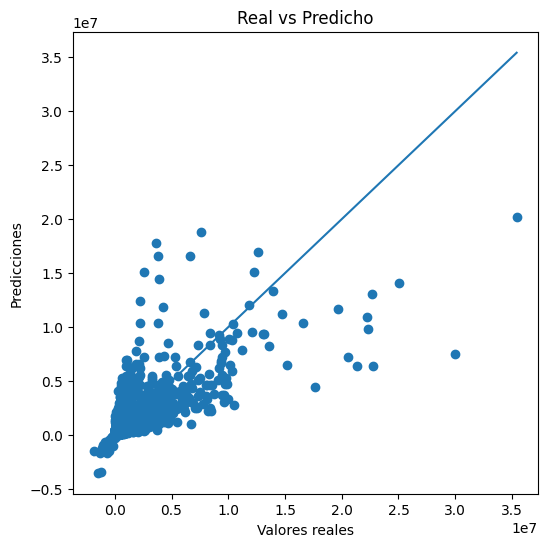

In [23]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

# Línea ideal (modelo perfecto)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho")

plt.show()

El gráfico de valores reales vs predichos permite evaluar visualmente el desempeño del modelo. Se observa que existe una tendencia positiva entre ambas variables, lo que indica que el modelo logra capturar parcialmente el comportamiento de la facturación.

Sin embargo, la dispersión de los puntos respecto de la línea ideal evidencia la presencia de errores de predicción, especialmente en valores elevados, lo cual es consistente con la variabilidad observada en el dataset.

In [24]:
importances = model.feature_importances_

features = X.columns

feat_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_importance.head(10)

,Feature,Importance
0,KilTot,0.721030
17,DesGrupo_VARIOS,0.147338
1,Mes,0.053273
7,CodZona_Sucursal 5,0.017445
10,DesGrupo_CARNE VACUNA,0.015188
9,CodZona_Ventas Directas,0.010441
2,CodZona_Libertad,0.007342
8,CodZona_Sunchales,0.004801
14,DesGrupo_MENUDENCIAS VACUNAS,0.004505
5,CodZona_Sucursal 3,0.004434


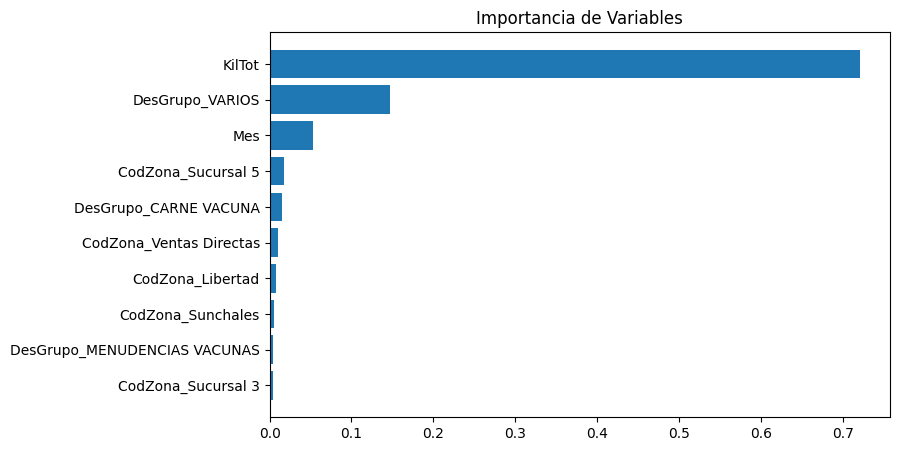

In [25]:
plt.figure(figsize=(8,5))
plt.barh(feat_importance['Feature'][:10], feat_importance['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Importancia de Variables")
plt.show()

El análisis de importancia de variables permite identificar cuáles son los factores más relevantes en la predicción de la facturación.

Se observa que el volumen vendido (KilTot) presenta un alto nivel de importancia, lo cual resulta consistente con la lógica del negocio. Asimismo, las variables categóricas asociadas a zona y grupo de producto también influyen en la predicción, evidenciando diferencias en el comportamiento comercial según segmento.

Este análisis aporta interpretabilidad al modelo y permite comprender mejor los drivers de la facturación.

En el presente trabajo se desarrolló un modelo de regresión utilizando Random Forest con el objetivo de predecir la facturación a partir de variables comerciales.

Se aplicó un método de selección de variables (SelectKBest) para reducir la dimensionalidad del dataset, cumpliendo con los requerimientos de la consigna.

Las métricas obtenidas (MAE, RMSE y R²) indican que el modelo presenta una capacidad predictiva moderada, logrando capturar parte de la variabilidad de la facturación.

El análisis de importancia de variables evidenció que el volumen vendido y las características del producto y la zona son factores determinantes en la predicción.

Como línea futura de mejora, se podrían incorporar variables adicionales como precios unitarios, promociones o características del cliente, con el objetivo de incrementar la precisión del modelo.